# Vizualization of datas

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import glob
import numpy as np
from PIL import Image
import os
import plotly.graph_objects as go
import plotly.express as px



#### Hyperparameters

In [33]:
dataset_addres = '..\\PBC_dataset_normal_DIB'


In [ ]:
df_classes = pd.DataFrame(
    {"Class Name":['Basophil','eosinophil','erythroblast',
                   'ig','lymphocyte','monocyte','neutrophil','platelet'],
     "Number Images": [1218,3117,1551,2895,1214,1420,3330,2348]})
df_classes

# **Read folder and images and Make a DataFrame**

In [ ]:
# For Windows because of \\ only work in windows os
data = []
for img_path in glob.glob(dataset_addres + "/*/*.jpg"):
    label = img_path.split('\\')[-2]
    data.append([img_path, label])
    
df = pd.DataFrame(data, columns=["image_path", "label"])
df.head()   

,image_path,label
0,..\PBC_dataset_normal_DIB\basophil\BA_100102.jpg,basophil
1,..\PBC_dataset_normal_DIB\basophil\BA_101381.jpg,basophil
2,..\PBC_dataset_normal_DIB\basophil\BA_101611.jpg,basophil
3,..\PBC_dataset_normal_DIB\basophil\BA_102039.jpg,basophil
4,..\PBC_dataset_normal_DIB\basophil\BA_102750.jpg,basophil


In [43]:
data=[]
for img_path in glob.glob(os.path.join(dataset_addres, "*", "*.jpg")):
    label = os.path.basename(os.path.dirname(img_path))
    data.append([img_path, label])

df = pd.DataFrame(data, columns=["image_path", "label"])
df.head()

,image_path,label
0,..\PBC_dataset_normal_DIB\basophil\BA_100102.jpg,basophil
1,..\PBC_dataset_normal_DIB\basophil\BA_101381.jpg,basophil
2,..\PBC_dataset_normal_DIB\basophil\BA_101611.jpg,basophil
3,..\PBC_dataset_normal_DIB\basophil\BA_102039.jpg,basophil
4,..\PBC_dataset_normal_DIB\basophil\BA_102750.jpg,basophil


In [46]:
class_counts = df["label"].value_counts()

print(class_counts)

imbalance_ratio = max(class_counts) / min(class_counts)

print("Imbalance ratio:", imbalance_ratio)

label
neutrophil      3329
eosinophil      3117
ig              2895
platelet        2348
erythroblast    1551
monocyte        1420
basophil        1218
lymphocyte      1214
Name: count, dtype: int64
Imbalance ratio: 2.742174629324547


To summarize the overall color characteristics of each image, the mean value of each channel was computed across all pixels. This operation reduces each image to a three-dimensional feature vector consisting of the average intensity of the red, green, and blue channels.

In [47]:
def get_mean_rgb(path):
    img = Image.open(path).convert("RGB")  # مهم برای consistency
    arr = np.array(img)
    return arr.mean(axis=(0,1))

means = np.array([get_mean_rgb(p) for p in df["image_path"]])

df[["R_mean", "G_mean", "B_mean"]] = means
df.head()

,image_path,label,R_mean,G_mean,B_mean
0,..\PBC_dataset_normal_DIB\basophil\BA_100102.jpg,basophil,224.147949,192.992011,181.520684
1,..\PBC_dataset_normal_DIB\basophil\BA_101381.jpg,basophil,216.880395,185.347467,180.204591
2,..\PBC_dataset_normal_DIB\basophil\BA_101611.jpg,basophil,218.369314,182.833157,181.483938
3,..\PBC_dataset_normal_DIB\basophil\BA_102039.jpg,basophil,212.396771,178.227456,180.590029
4,..\PBC_dataset_normal_DIB\basophil\BA_102750.jpg,basophil,226.372008,194.938162,184.035889


In [18]:
df["image_path"].iloc[1]
img = Image.open(df["image_path"].iloc[1]).convert("L")
arr = np.array(img)
arr


array([[234, 234, 234, ..., 233, 231, 230],
       [234, 234, 234, ..., 233, 231, 231],
       [234, 234, 234, ..., 232, 232, 231],
       ...,
       [237, 234, 232, ..., 178, 178, 178],
       [236, 234, 232, ..., 178, 178, 179],
       [234, 232, 231, ..., 178, 178, 179]], shape=(363, 360), dtype=uint8)

In [48]:
df.to_csv("dataset.csv", index=False, encoding="utf-8")

#### Create feature for Grayscale

In [22]:
def get_mean_gray(path):
    img = Image.open(path).convert("L")  # L = Grayscale
    arr = np.array(img)
    return arr.mean()

df["Gray_mean"] = df["image_path"].apply(get_mean_gray)

In [24]:
df.to_csv("dataset.csv", index=False, encoding="utf-8")

# **Load DataFrame and ...**

In [25]:
df = pd.read_csv('dataset.csv')
df.head()

,image_path,label,R_mean,G_mean,B_mean,hash,Gray_mean
0,..\PBC_dataset_normal_DIB\basophil\BA_100102.jpg,basophil,224.147949,192.992011,181.520684,f24406368058b3be5f7173b55f4523e29476bdf912120f...,201.010736
1,..\PBC_dataset_normal_DIB\basophil\BA_101381.jpg,basophil,216.880395,185.347467,180.204591,5e81b38623baec9b5f6e6a64fefa0d5afe055e73ff2eb6...,194.197720
2,..\PBC_dataset_normal_DIB\basophil\BA_101611.jpg,basophil,218.369314,182.833157,181.483938,0e1ea3f0b635f721a31650c0fea1be9bace526178636fa...,193.350811
3,..\PBC_dataset_normal_DIB\basophil\BA_102039.jpg,basophil,212.396771,178.227456,180.590029,2de531781db2946d4940ed267f53bd1b1e028c54fb862f...,188.760055
4,..\PBC_dataset_normal_DIB\basophil\BA_102750.jpg,basophil,226.372008,194.938162,184.035889,22e52477ef7d3c1e67e93ef48b5d95c86727b175a716c8...,203.143580


# **EDA**

#### **1. Dataset Overview** 

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17092 entries, 0 to 17091
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   image_path  17092 non-null  str    
 1   label       17092 non-null  str    
 2   R_mean      17092 non-null  float64
 3   G_mean      17092 non-null  float64
 4   B_mean      17092 non-null  float64
dtypes: float64(3), str(2)
memory usage: 1.6 MB


#### **2. Data Quality Check**

In [11]:
df.isnull().sum()

image_path    0
label         0
R_mean        0
G_mean        0
B_mean        0
hash          0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

**Is there any duplicate images? same kpics with different name**

In [6]:
import hashlib

img = df["image_path"][0]
img = Image.open(img).convert("RGB")
hashlib.sha256(img.tobytes()).hexdigest()


'f24406368058b3be5f7173b55f4523e29476bdf912120ff81f4f663c5e913049'

In [ ]:
import hashlib
from PIL import Image

def image_hash(path):
    img = Image.open(path).convert("RGB")
    return hashlib.sha256(img.tobytes()).hexdigest()

In [8]:
df["hash"] = df["image_path"].apply(image_hash)

#### add hash as a column to avoid run this function each time

In [ ]:
df.to_csv("dataset.csv", index=False, encoding="utf-8")

In [13]:
df.duplicated("hash").sum()

np.int64(17)

In [16]:
duplicates = df.loc[df.duplicated("hash", keep=False),['image_path', 'label', 'hash']].sort_values(by='hash')
duplicates.head(4)

,image_path,label,hash
4131,..\PBC_dataset_normal_DIB\eosinophil\EO_941266...,eosinophil,103a72fc8729ce3a98d20d841936b9c1a3cdb05c5694bb...
4310,..\PBC_dataset_normal_DIB\eosinophil\EO_994040...,eosinophil,103a72fc8729ce3a98d20d841936b9c1a3cdb05c5694bb...
122,..\PBC_dataset_normal_DIB\basophil\BA_20201.jpg,basophil,13bef6d6822fbd149eb6090179e09e8761fb83805caeaa...
958,..\PBC_dataset_normal_DIB\basophil\BA_809918.jpg,basophil,13bef6d6822fbd149eb6090179e09e8761fb83805caeaa...


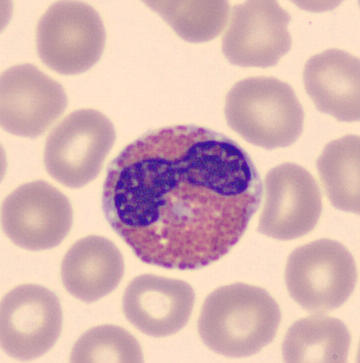

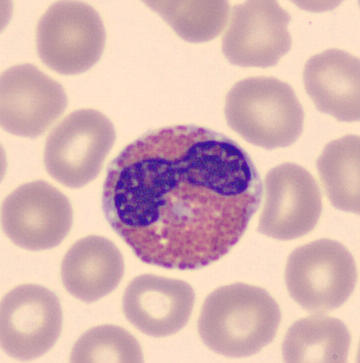

In [22]:
#display(Image.open(duplicates.iloc[0]['image_path']))
#display(Image.open(duplicates.iloc[1]['image_path']))

img_1 = '../PBC_dataset_normal_DIB/eosinophil/EO_941266.jpg'
img_2 = '../PBC_dataset_normal_DIB/eosinophil/EO_994040.jpg'

display(Image.open(img_1))
display(Image.open(img_2))


In [61]:
duplicates.groupby(by=['label','hash']).count()

image_path
label      hash                                                          
basophil   13bef6d6822fbd149eb6090179e09e8761fb83805caeaae...           2
           1c1507e3c37a24701b69327d473c449b92310da405abdd9...           2
           9d6adbe07831458060d41ef01f96fbd2b28abc503babe17...           2
           b64210e06abc8ac904ee81819f36aa8f5217b21f4a41029...           2
           d8db113165f62f4858b6b2794e0e6581ad47d07c35c315e...           2
           ef39a2398d6129b76ad6b500afab116be4823097c2490f6...           2
eosinophil 103a72fc8729ce3a98d20d841936b9c1a3cdb05c5694bb6...           2
           2afad8807a95fd07b3fa71143e29a88e31079b2e7e443ab...           2
           37a728b05dc98139d1f0cfbe8bda60183007236d0c4edc9...           2
           52a23e50d270309559db5d7a9dfc3c5dea858fdbb3b6b7e...           1
           701a427b6496e80f7a42b0b2b0ce49edc979cd5b8b96bd2...           2
           a8f5187339000d00933da40fed78b64581e336d9b886df3...           2
           d38f1327f08a0bda123f943d200e43a5aa74960ef4ac43a...           2
ig         2a46aa756b98a4d899ba1507c91402761a84620cb7b6c4c...           2
           2c25fdc23b8e395c628848c3966013657ce4faf014d0299...           2
           b2aad3717f0a87e689f0c464cf44dda27123c34363f35c5...           2
monocyte   84ea0d39fe6d4e882c17a583823f1614360ef78768d5ebb...           2
neutrophil 52a23e50d270309559db5d7a9dfc3c5dea858fdbb3b6b7e...           1

In [74]:
grouped = duplicates.groupby(["label", "hash"])["image_path"].apply(list)
grouped_df = grouped.reset_index()
grouped_df

,label,hash,image_path
0,basophil,13bef6d6822fbd149eb6090179e09e8761fb83805caeaa...,[..\PBC_dataset_normal_DIB\basophil\BA_20201.j...
1,basophil,1c1507e3c37a24701b69327d473c449b92310da405abdd...,[..\PBC_dataset_normal_DIB\basophil\BA_225540....
2,basophil,9d6adbe07831458060d41ef01f96fbd2b28abc503babe1...,[..\PBC_dataset_normal_DIB\basophil\BA_546746....
3,basophil,b64210e06abc8ac904ee81819f36aa8f5217b21f4a4102...,[..\PBC_dataset_normal_DIB\basophil\BA_435917....
4,basophil,d8db113165f62f4858b6b2794e0e6581ad47d07c35c315...,[..\PBC_dataset_normal_DIB\basophil\BA_251042....
5,basophil,ef39a2398d6129b76ad6b500afab116be4823097c2490f...,[..\PBC_dataset_normal_DIB\basophil\BA_381452....
6,eosinophil,103a72fc8729ce3a98d20d841936b9c1a3cdb05c5694bb...,[..\PBC_dataset_normal_DIB\eosinophil\EO_94126...
7,eosinophil,2afad8807a95fd07b3fa71143e29a88e31079b2e7e443a...,[..\PBC_dataset_normal_DIB\eosinophil\EO_62185...
8,eosinophil,37a728b05dc98139d1f0cfbe8bda60183007236d0c4edc...,[..\PBC_dataset_normal_DIB\eosinophil\EO_22012...
9,eosinophil,52a23e50d270309559db5d7a9dfc3c5dea858fdbb3b6b7...,[..\PBC_dataset_normal_DIB\eosinophil\EO_22590...


In [99]:
# make a dictionary with keys: hash and values: image_addres 
# because heat = duplicates.groupby(["label", "hash"]).size().unstack().fillna(0)
# give us hash's as columns.headers but we want to draw heatmap respect to the
# name of files as x_axis
 
hash_to_path = grouped_df.drop_duplicates("hash").set_index("hash")["image_path"].to_dict()
hash_to_path

{'13bef6d6822fbd149eb6090179e09e8761fb83805caeaaed815eaeac476b6d3e': ['..\\PBC_dataset_normal_DIB\\basophil\\BA_20201.jpg',
  '..\\PBC_dataset_normal_DIB\\basophil\\BA_809918.jpg'],
 '1c1507e3c37a24701b69327d473c449b92310da405abdd9a85c649e179a6d427': ['..\\PBC_dataset_normal_DIB\\basophil\\BA_225540.jpg',
  '..\\PBC_dataset_normal_DIB\\basophil\\BA_786369.jpg'],
 '9d6adbe07831458060d41ef01f96fbd2b28abc503babe17b75e90f74f41aceeb': ['..\\PBC_dataset_normal_DIB\\basophil\\BA_546746.jpg',
  '..\\PBC_dataset_normal_DIB\\basophil\\BA_685720.jpg'],
 'b64210e06abc8ac904ee81819f36aa8f5217b21f4a410292269af89169a498f5': ['..\\PBC_dataset_normal_DIB\\basophil\\BA_435917.jpg',
  '..\\PBC_dataset_normal_DIB\\basophil\\BA_858229.jpg'],
 'd8db113165f62f4858b6b2794e0e6581ad47d07c35c315eec043074522a294c7': ['..\\PBC_dataset_normal_DIB\\basophil\\BA_251042.jpg',
  '..\\PBC_dataset_normal_DIB\\basophil\\BA_988506.jpg'],
 'ef39a2398d6129b76ad6b500afab116be4823097c2490f63efb74bcd32fb47ef': ['..\\PBC_dataset

In [105]:
heat = duplicates.groupby(["label", "hash"]).size().unstack().fillna(0)
heat

hash,103a72fc8729ce3a98d20d841936b9c1a3cdb05c5694bb642da0416b83dd5c73,13bef6d6822fbd149eb6090179e09e8761fb83805caeaaed815eaeac476b6d3e,1c1507e3c37a24701b69327d473c449b92310da405abdd9a85c649e179a6d427,2a46aa756b98a4d899ba1507c91402761a84620cb7b6c4c79388bae206fb397b,2afad8807a95fd07b3fa71143e29a88e31079b2e7e443abb80be76790fa3d334,2c25fdc23b8e395c628848c3966013657ce4faf014d0299887460b162f79fd86,37a728b05dc98139d1f0cfbe8bda60183007236d0c4edc9ad13e57d47acb9fc3,52a23e50d270309559db5d7a9dfc3c5dea858fdbb3b6b7e102e8be0e3535326b,701a427b6496e80f7a42b0b2b0ce49edc979cd5b8b96bd2aefd982e97e109b2d,84ea0d39fe6d4e882c17a583823f1614360ef78768d5ebb1923ec32a8346e1ed,9d6adbe07831458060d41ef01f96fbd2b28abc503babe17b75e90f74f41aceeb,a8f5187339000d00933da40fed78b64581e336d9b886df3acf5735b4fad0e0ba,b2aad3717f0a87e689f0c464cf44dda27123c34363f35c5a9a969eb3f1f9dcee,b64210e06abc8ac904ee81819f36aa8f5217b21f4a410292269af89169a498f5,d38f1327f08a0bda123f943d200e43a5aa74960ef4ac43a6d9f807bbb90dd6fc,d8db113165f62f4858b6b2794e0e6581ad47d07c35c315eec043074522a294c7,ef39a2398d6129b76ad6b500afab116be4823097c2490f63efb74bcd32fb47ef
label,,,,,,,,,,,,,,,,,
basophil,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,2.0,0.0,2.0,2.0
eosinophil,2.0,0.0,0.0,0.0,2.0,0.0,2.0,1.0,2.0,0.0,0.0,2.0,0.0,0.0,2.0,0.0,0.0
ig,0.0,0.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0
monocyte,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
neutrophil,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


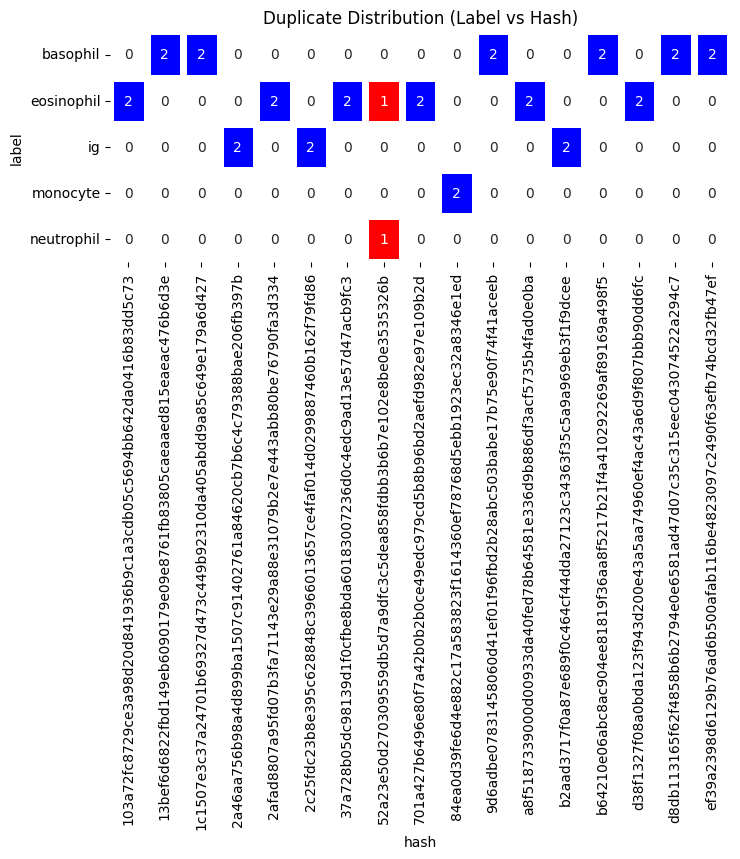

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cmap = ListedColormap(["white", "red", "blue"])
plt.figure(figsize=(8,3))
sns.heatmap(heat, cmap=cmap,linewidths=5,cbar=False,annot=True)
plt.title("Duplicate Distribution (Label vs Hash)")
plt.show()

### **4. Descriptive Statistical Analysis**

In [7]:
des = df.groupby("label")[["R_mean","G_mean","B_mean"]].describe()
des

R_mean                                                \
               count        mean       std         min         25%   
label                                                                
basophil      1218.0  220.048263  5.823719  193.893978  216.770122   
eosinophil    3117.0  222.176817  5.827041  193.051010  219.038874   
erythroblast  1551.0  228.290703  8.115238  194.767042  224.779060   
ig            2895.0  217.281036  8.005190  174.514073  212.721928   
lymphocyte    1214.0  223.124070  5.597512  191.095688  220.566990   
monocyte      1420.0  215.912685  5.933071  185.299816  212.686017   
neutrophil    3329.0  222.146791  5.659801  190.950482  218.732744   
platelet      2348.0  233.365231  4.929630  203.579316  230.270763   

                                                  G_mean              ...  \
                     50%         75%         max   count        mean  ...   
label                                                                 ...   
basophil      220.720849  224.023297  234.247919  1218.0  187.953521  ...   
eosinophil    222.640090  226.143151  239.115718  3117.0  188.656194  ...   
erythroblast  230.339203  233.960059  246.123913  1551.0  198.276726  ...   
ig            218.495921  223.067818  237.022513  2895.0  185.661159  ...   
lymphocyte    223.771396  226.645766  239.906359  1214.0  191.674115  ...   
monocyte      216.526718  219.771183  230.271457  1420.0  183.868039  ...   
neutrophil    222.685323  225.980471  236.524709  3329.0  189.908148  ...   
platelet      233.666211  236.806944  252.353436  2348.0  202.296944  ...   

                                      B_mean                        \
                     75%         max   count        mean       std   
label                                                                
basophil      192.019886  205.176684  1218.0  183.649320  6.186660   
eosinophil    193.003290  209.627816  3117.0  182.449413  4.745882   
erythroblast  203.715672  220.535484  1551.0  187.398531  6.176268   
ig            191.265672  208.140312  2895.0  183.218722  7.183462   
lymphocyte    195.349946  210.629094  1214.0  183.917446  5.975741   
monocyte      187.841594  201.938590  1420.0  182.411102  6.038693   
neutrophil    194.167654  208.196717  3329.0  182.974929  5.119651   
platelet      206.075693  224.794322  2348.0  187.431526  2.954347   

                                                                          
                     min         25%         50%         75%         max  
label                                                                     
basophil      170.069223  180.789438  182.803528  184.710199  215.682327  
eosinophil    167.824893  180.148967  182.215748  184.176676  220.449442  
erythroblast  172.257897  184.766850  187.245906  189.310009  222.522369  
ig            166.518809  179.646097  182.283655  184.765745  221.183542  
lymphocyte    171.780142  181.082679  182.998558  184.958634  216.182046  
monocyte      166.554339  179.763479  181.638170  183.589815  218.214773  
neutrophil    166.059014  180.659099  182.702785  184.642616  223.489071  
platelet      170.152785  185.648820  187.514451  189.404505  200.732698  

[8 rows x 24 columns]

In [8]:
avg_light_intencity_red = des['R_mean']['mean']
avg_light_intencity_green = des['G_mean']['mean']
avg_light_intencity_blue = des['B_mean']['mean']

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=avg_light_intencity_red.index,
        y=avg_light_intencity_red,
        name='Red Channel'
    )
)

fig.add_trace(
    go.Bar(
        x=avg_light_intencity_green.index,
        y=avg_light_intencity_green,
        name='Green Channel'
    )
)

fig.add_trace(
    go.Bar(
        x=avg_light_intencity_blue.index,
        y=avg_light_intencity_blue,
        name='Blue Channel'
    )
)

fig.update_layout(
    title='Average RGB Intensity per Blood Cell Class',
    xaxis_title='Cell Class',
    yaxis_title='Average Intensity',
    barmode='group',  
    width=1000,
    height=600
)

fig.show()


In [9]:
avg_light_intencity_red = des['R_mean']['mean']
avg_light_intencity_green = des['G_mean']['mean']
avg_light_intencity_blue = des['B_mean']['mean']

overall_avg_intensity = (
    avg_light_intencity_red +
    avg_light_intencity_green +
    avg_light_intencity_blue
) / 3

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=overall_avg_intensity.index,
        y=overall_avg_intensity,
        text=overall_avg_intensity.round(2),
        textposition='outside',
        name='Average RGB Intensity'
    )
)

fig.update_layout(
    title='Average Overall Light Intensity per Blood Cell Class',
    xaxis_title='Cell Class',
    yaxis_title='Average Intensity',
    width=1000,
    height=600
)

fig.show()


### **Correlation between RGB features**

In [10]:
corr = df[["R_mean", "G_mean", "B_mean"]].corr()
corr

,R_mean,G_mean,B_mean
R_mean,1.000000,0.930264,0.318389
G_mean,0.930264,1.000000,0.589185
B_mean,0.318389,0.589185,1.000000


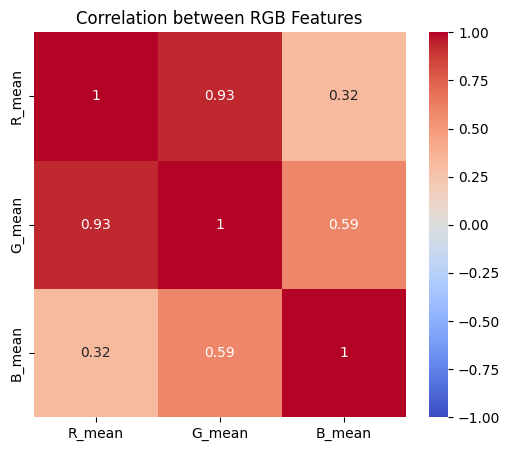

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation between RGB Features")
plt.show()

### **RGB feature distributions**

In [12]:
import plotly.express as px

fig = px.histogram(df, x="R_mean", nbins=50, title="Distribution of R_mean")
fig.show()

fig = px.histogram(df, x="G_mean", nbins=50, title="Distribution of G_mean")
fig.show()

fig = px.histogram(df, x="B_mean", nbins=50, title="Distribution of B_mean")
fig.show()

In [13]:
import plotly.express as px

df_melted = df.melt(
    id_vars="label",
    value_vars=["R_mean", "G_mean", "B_mean"],
    var_name="Channel",
    value_name="Intensity"
)

fig = px.box(
    df_melted,
    x="Channel",
    y="Intensity",
    color="Channel",
    title="RGB Feature Distributions (Boxplot)"
)

fig.show()

In [14]:
fig = px.box(
    df,
    x="label",
    y="R_mean",
    title="R_mean Distribution Across Classes"
)

fig.show()

In [21]:
df_melted = df.melt(
    id_vars="label",
    value_vars=["R_mean", "G_mean", "B_mean"],
    var_name="Channel",
    value_name="Intensity"
)

fig = px.violin(
    df_melted,
    x="label",
    y="Intensity",
    color="Channel",
    box=True,
    points="all",
    title="RGB Distribution per Class (Violin + Boxplot)"
)
fig.update_layout(
    width=1200,
    height=1000
)
fig.show()

#### Gray_Scale

In [26]:
import plotly.express as px

px.histogram(df, x="Gray_mean", nbins=50, title="Distribution of Gray Intensity").show()

In [27]:
px.box(df, x="label", y="Gray_mean", title="Gray Intensity per Class").show()

In [28]:
df['Gray_mean'].describe()

count    17092.000000
mean       199.700587
std          7.889287
min        153.020960
25%        194.714497
50%        199.491728
75%        204.695996
max        230.443251
Name: Gray_mean, dtype: float64

In [29]:
px.violin(df, x="label", y="Gray_mean", box=True, points="all",
          title="Gray Distribution per Class").show()

In [13]:
import plotly.express as px

counts = (
    df['label']
    .value_counts()
    .sort_values()
    .reset_index()
)

counts.columns = ['Class Name', 'Number Images']

fig = px.bar(
    counts,
    x="Class Name",
    y="Number Images",
    text="Number Images",
    title="Blood Cell Class Distribution (Sorted)"
)

fig.update_traces(textposition="outside")

fig.update_layout(
    width=900,
    height=600,
    xaxis_tickangle=-45
)

fig.show()